#From-Fundamentals-to-Scale-A-Comprehensive-Framework-for-Understanding-Modern-System-Design
## Author: Anshuman Sinha

### Experimental Demonstration: To provide practical support for the proposed educational framework, a simulation-based experiment was conducted using Python in Google Colab. The experiment modeled a distributed system incorporating a load balancer, application servers, a caching layer, and a database backend. Performance metrics were compared under two conditions: with and without caching. The results indicated substantial reductions in average response latency when caching mechanisms were employed, while load balancing ensured equitable traffic distribution across servers. These findings reinforce the central premise of the framework that architectural decisions directly influence non-functional requirements such as scalability and performance.

===== PERFORMANCE COMPARISON =====
        Scenario  Average Latency (ms)  95th Percentile (ms)  \
0  Without Cache             75.225140             97.570735   
1     With Cache             24.721761             90.981625   

   Maximum Latency (ms)  
0             99.995604  
1             99.998531  

===== LOAD BALANCER DISTRIBUTION =====
Server 1: 2562 requests
Server 2: 2482 requests
Server 3: 2508 requests
Server 4: 2448 requests


/tmp/ipykernel_4828/249891678.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


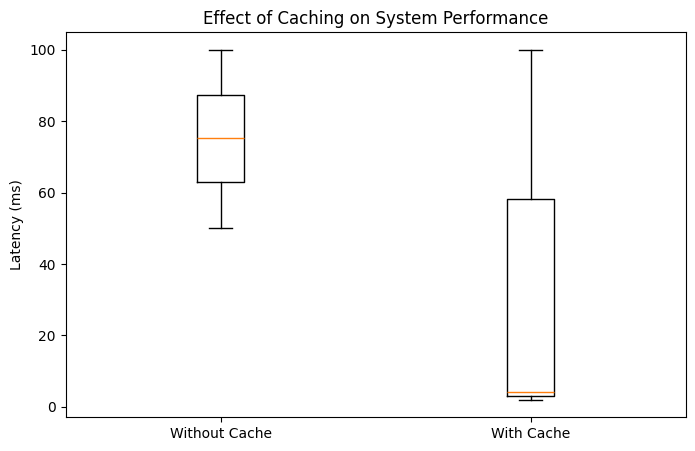

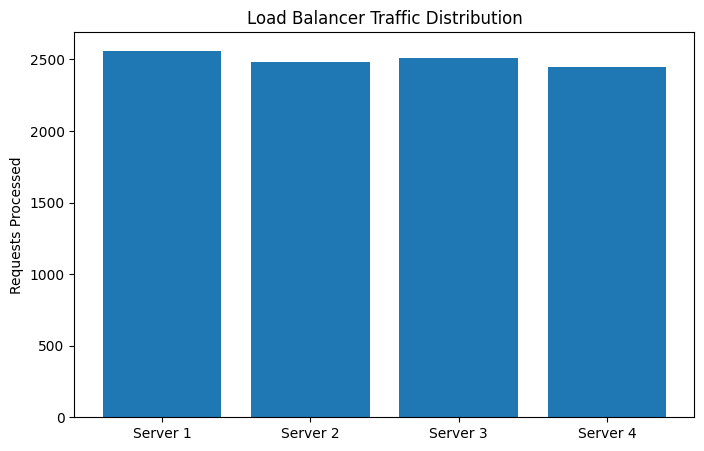


===== EXPERIMENTAL FINDINGS =====
Latency reduction due to caching: 67.14%
The experiment demonstrates that architectural components such as caching and load balancing significantly influence system quality attributes including performance and scalability.


In [1]:
# ==========================================
# Demonstration Experiment for: "From Fundamentals to Scale: A Comprehensive Framework for Understanding Modern System Design"
# ==========================================

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Simulation Parameters
# -----------------------------
NUM_REQUESTS = 10000
NUM_SERVERS = 4
CACHE_HIT_RATE = 0.70

# Latency assumptions (milliseconds)
CACHE_LATENCY = (2, 5)
DATABASE_LATENCY = (50, 100)

# -----------------------------
# Scenario 1: Without Cache
# -----------------------------
without_cache = []

for _ in range(NUM_REQUESTS):
    latency = random.uniform(*DATABASE_LATENCY)
    without_cache.append(latency)

# -----------------------------
# Scenario 2: With Cache
# -----------------------------
with_cache = []

for _ in range(NUM_REQUESTS):

    if random.random() < CACHE_HIT_RATE:
        latency = random.uniform(*CACHE_LATENCY)
    else:
        latency = random.uniform(*DATABASE_LATENCY)

    with_cache.append(latency)

# -----------------------------
# Load Balancer Simulation
# -----------------------------
server_load = [0] * NUM_SERVERS

for _ in range(NUM_REQUESTS):
    server = random.randint(0, NUM_SERVERS - 1)
    server_load[server] += 1

# -----------------------------
# Metrics
# -----------------------------
results = pd.DataFrame({
    "Scenario": ["Without Cache", "With Cache"],
    "Average Latency (ms)": [
        np.mean(without_cache),
        np.mean(with_cache)
    ],
    "95th Percentile (ms)": [
        np.percentile(without_cache, 95),
        np.percentile(with_cache, 95)
    ],
    "Maximum Latency (ms)": [
        np.max(without_cache),
        np.max(with_cache)
    ]
})

print("===== PERFORMANCE COMPARISON =====")
print(results)

print("\n===== LOAD BALANCER DISTRIBUTION =====")

for i, load in enumerate(server_load):
    print(f"Server {i+1}: {load} requests")

# -----------------------------
# Visualization 1:
# Latency Comparison
# -----------------------------

plt.figure(figsize=(8,5))

plt.boxplot(
    [without_cache, with_cache],
    labels=["Without Cache", "With Cache"]
)

plt.ylabel("Latency (ms)")
plt.title("Effect of Caching on System Performance")

plt.show()

# -----------------------------
# Visualization 2:
# Server Distribution
# -----------------------------

plt.figure(figsize=(8,5))

plt.bar(
    [f"Server {i+1}" for i in range(NUM_SERVERS)],
    server_load
)

plt.ylabel("Requests Processed")
plt.title("Load Balancer Traffic Distribution")

plt.show()

# -----------------------------
# Conclusion
# -----------------------------

improvement = (
    (np.mean(without_cache) - np.mean(with_cache))
    / np.mean(without_cache)
) * 100

print("\n===== EXPERIMENTAL FINDINGS =====")

print(f"Latency reduction due to caching: {improvement:.2f}%")

print(
    "The experiment demonstrates that architectural "
    "components such as caching and load balancing "
    "significantly influence system quality attributes "
    "including performance and scalability."
)